In [1]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns

plt.rc('font', size=7.5, weight='normal')

In [2]:
import gurobipy as gp
from gurobipy import GRB

def MILP_optimization(para_theta_i_p, 
                      para_theta_i_n, 
                      #holding_cost_change, 
                      fixed_cost,
                      force_no_ai=False, 
                      server_capacity=50,
                      print_details=True):

    queue_length = {"MDD": 0, "AD": 0, "PTSD": 0}
    waiting_time = {"MDD": 0, "AD": 0, "PTSD": 0}
    Z = {"MDD": 0, "AD": 0, "PTSD": 0}
    Y = {"MDD": 0, "AD": 0, "PTSD": 0}
    W = {"MDD": 0, "AD": 0, "PTSD": 0}
    
    I = ["MDD", "AD", "PTSD"]

    lambda_i = {"MDD": 81, "AD": 57, "PTSD": 113} 
    b_i = {"MDD": 12_000, "AD": 9_000, "PTSD": 13_000}
    f_i = {i: fixed_cost for i in I}
    h_i = {"MDD": 324.12, "AD": 196.13, "PTSD": 377.50}
    drop_i = {i: b_i[i] for i in I}

    beta = 1 - 0.18
    mu_i = {
        "MDD": beta / 13.5 * 40,
        "AD": beta / 13.5 * 40,
        "PTSD": beta / 12 * 40,
    }

    gamma_i = {i: 0.0067 for i in I}
    theta_i = {i: 0.04 for i in I}
    theta_i_p = {i: para_theta_i_p for i in I}
    theta_i_n = {i: para_theta_i_n for i in I}
    theta_i_w = {i: theta_i_p[i] + theta_i_n[i] for i in I}

    alpha_i = {"MDD": 240, "AD": 180, "PTSD": 260}
    alpha_i_n = {"MDD": 120, "AD": 90, "PTSD": 130}
    a_i = {i: 1 for i in I}
    h_i_w = {
    "MDD": h_i["MDD"] * 0.1,
    "AD": h_i["AD"] * 0.1,
    "PTSD": h_i["PTSD"] * 0.1
 }

    c_i = {i: h_i[i] + alpha_i[i] * theta_i[i] for i in I}
    c_i_w = {i: h_i_w[i] + alpha_i_n[i] * theta_i_n[i] - b_i[i] * theta_i_p[i] + a_i[i] for i in I}

    r_i = {i: b_i[i] * mu_i[i] - gamma_i[i] * drop_i[i] for i in I}

    P_i = {
        i: (r_i[i] * theta_i[i] + c_i[i] * (mu_i[i] + gamma_i[i])) / theta_i[i]
        for i in I
    }

    P_i_w = {
        i: (r_i[i] * theta_i_w[i] + c_i_w[i] * (mu_i[i] + gamma_i[i])) / theta_i_w[i]
        for i in I
    }

    z_max = {i: lambda_i[i] / (mu_i[i] + gamma_i[i]) for i in I}

    model = gp.Model("MentalHealth_MILP")
    model.setParam('OutputFlag', 0)
    
    z = model.addVars(I, name="z", lb=0.0, ub=z_max, vtype=GRB.CONTINUOUS)
    y = model.addVars(I, name="y", lb=0.0, vtype=GRB.CONTINUOUS)
    w = model.addVars(I, name="w", vtype=GRB.BINARY)

    if force_no_ai:
        for i in I:
            model.addConstr(w[i] == 0)

    for i in I:
        model.addConstr(y[i] <= z_max[i] * w[i])
        model.addConstr(y[i] >= z[i] - z_max[i] * (1 - w[i]))
        model.addConstr(y[i] <= z[i])

    model.addConstr(gp.quicksum(z[i] for i in I) <= server_capacity)

    model.setObjective(
        gp.quicksum(
            (P_i[i] * (z[i] - y[i]) + P_i_w[i] * y[i]) -
            lambda_i[i] * ((c_i[i] / theta_i[i]) * (1 - w[i]) + (c_i_w[i] / theta_i_w[i]) * w[i]) -
            f_i[i] * w[i]
            for i in I
        ),
        GRB.MAXIMIZE
    )

    model.optimize()

    bar_P_i = {}

    if model.status == GRB.OPTIMAL:
        opt_obj = model.ObjVal
        for i in I:
            queue_length[i] = ((1 - w[i].X) / theta_i[i] + w[i].X / theta_i_w[i]) * lambda_i[i] - \
                              (mu_i[i] + gamma_i[i]) * ((1 - w[i].X) / theta_i[i] + w[i].X / theta_i_w[i]) * z[i].X
            waiting_time[i] = queue_length[i] / lambda_i[i]
            Z[i] = z[i].X
            Y[i] = y[i].X
            W[i] = int(w[i].X)
            bar_P_i[i] = P_i[i] * (1 - w[i].X) + P_i_w[i] * w[i].X
        if print_details:
            print("✅ Optimal solution found. Objective value: {:.2f}".format(opt_obj))
    else:
        opt_obj = None
        if print_details:
            print("❌ No optimal solution found.")

    return Z, W, queue_length, waiting_time, P_i, P_i_w, bar_P_i, opt_obj


In [3]:
Z, W, queue_length, waiting_time, P_i, P_i_w, bar_P_i, opt_obj = MILP_optimization(

            para_theta_i_p=0.06,
            para_theta_i_n=0.0005,
            force_no_ai=False,
            #holding_cost_change=0.01,
            fixed_cost=640,
            print_details=False,
            server_capacity=50
        )
bar_P_i


print('Z: ', Z)
print('W: ', W)
print('queue_length: ', queue_length)
print('waiting_time: ', waiting_time)
print('P_i: ', P_i)
print('P_i_w: ', P_i_w)
print('bar_P_i: ', bar_P_i)
print('opt_obj:', opt_obj)

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-23
Z:  {'MDD': 8.759625795306633, 'AD': 0.0, 'PTSD': 41.24037420469337}
W:  {'MDD': 1, 'AD': 1, 'PTSD': 0}
queue_length:  {'MDD': 986.0936219905198, 'AD': 942.1487603305786, 'PTSD': 0.0}
waiting_time:  {'MDD': 12.173995333216293, 'AD': 16.528925619834713, 'PTSD': 0.0}
P_i:  {'MDD': 49401.45365555556, 'AD': 34190.83925648149, 'PTSD': 62017.70658333335}
P_i_w:  {'MDD': 1428.7339362105877, 'AD': 892.5104268135944, 'PTSD': 1878.1076115702558}
bar_P_i:  {'MDD': 1428.7339362105877, 'AD': 892.5104268135944, 'PTSD': 62017.70658333335}
opt_obj: 2881501.7130260505


In [4]:
Z, W, queue_length, waiting_time, P_i, P_i_w, bar_P_i, opt_obj = MILP_optimization(
            para_theta_i_p=0.06,
            para_theta_i_n=0.0005,
            force_no_ai=True,
            #holding_cost_change=0.01,
            fixed_cost=640,
            print_details=False,
            server_capacity=50
        )
bar_P_i


print('Z: ', Z)
print('W: ', W)
print('queue_length: ', queue_length)
print('waiting_time: ', waiting_time)
print('P_i: ', P_i)
print('P_i_w: ', P_i_w)
print('bar_P_i: ', bar_P_i)
print('opt_obj:', opt_obj)

Z:  {'MDD': 8.759625795306633, 'AD': 0.0, 'PTSD': 41.24037420469337}
W:  {'MDD': 0, 'AD': 0, 'PTSD': 0}
queue_length:  {'MDD': 1491.466603260661, 'AD': 1425.0, 'PTSD': 0.0}
waiting_time:  {'MDD': 18.413167941489643, 'AD': 25.0, 'PTSD': 0.0}
P_i:  {'MDD': 49401.45365555556, 'AD': 34190.83925648149, 'PTSD': 62017.70658333335}
P_i_w:  {'MDD': 1428.7339362105877, 'AD': 892.5104268135944, 'PTSD': 1878.1076115702558}
bar_P_i:  {'MDD': 49401.45365555556, 'AD': 34190.83925648149, 'PTSD': 62017.70658333335}
opt_obj: 929025.924580392


Total runtime: 1.61 seconds


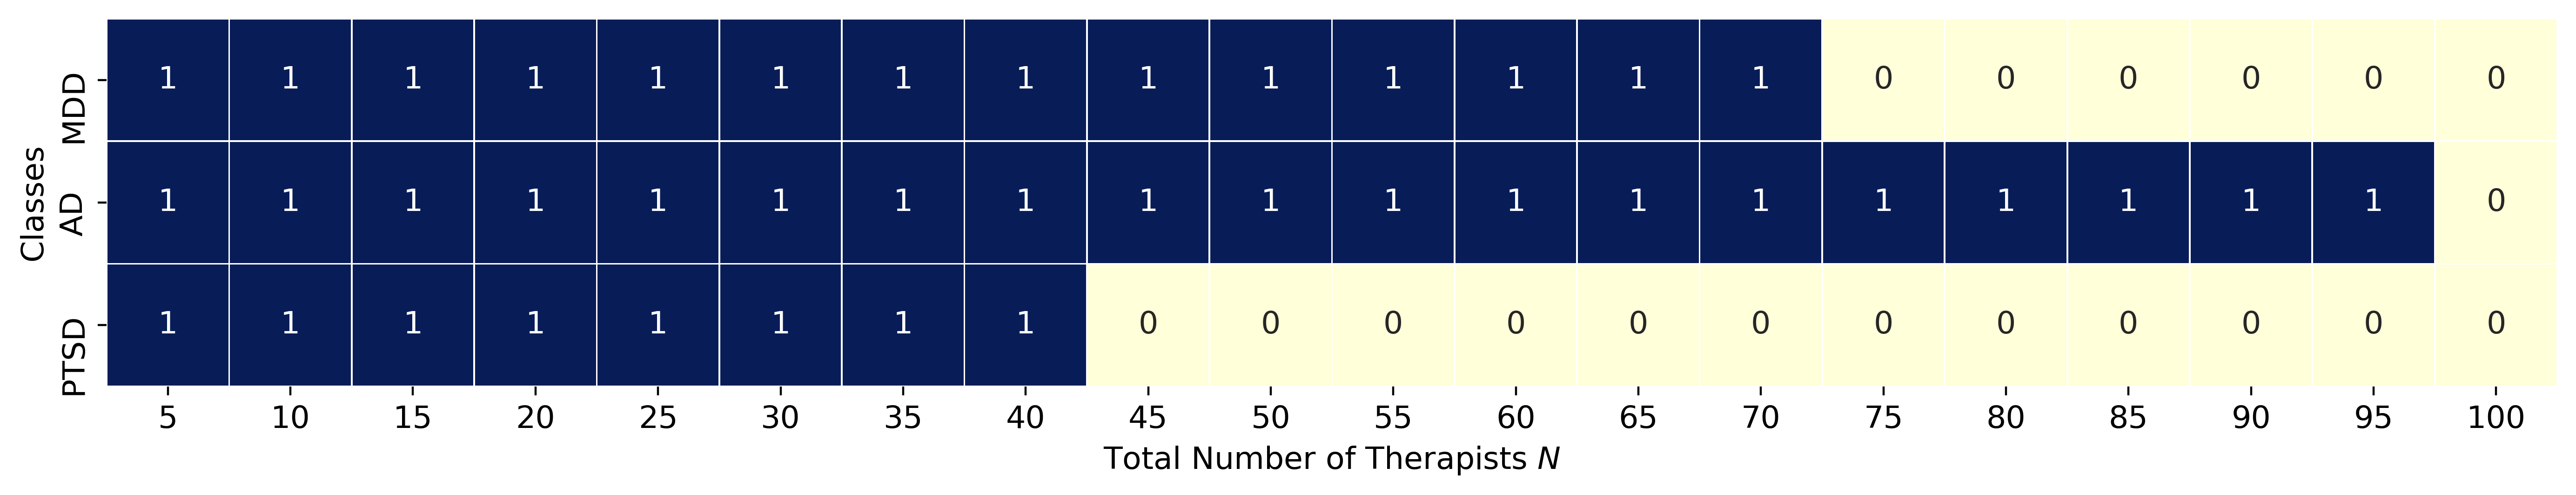

In [5]:
import time

start_time = time.perf_counter()


# === Parameters ===
classes = ["MDD", "AD", "PTSD"]
server_caps = np.arange(5, 105, 5)
server_labels = [str(val) for val in server_caps]

# === Matrix (rows: classes, cols: server capacities) ===
w_matrix = np.zeros((len(classes), len(server_caps)))

queue_length_MDD = []
queue_length_AD = []
queue_length_PTSD = []

server_MDD = []
server_AD = []
server_PTSD = []

# === Run optimization and collect w_i ===
for j, cap in enumerate(server_caps):
    Z, W, queue_length, waiting_time, P_i, P_i_w, bar_P_i, opt_obj = MILP_optimization(
        para_theta_i_p=0.06,
        para_theta_i_n=0.0005,
        force_no_ai=False,
        fixed_cost=640,
        print_details=False,
        server_capacity=cap  
    )

    queue_length_MDD.append(queue_length['MDD'])
    queue_length_AD.append(queue_length['AD'])
    queue_length_PTSD.append(queue_length['PTSD'])
    server_MDD.append(Z['MDD']) 
    server_AD.append(Z['AD'])   
    server_PTSD.append(Z['PTSD']) 

    for i, cls in enumerate(classes):
        w_matrix[i, j] = W[cls]  

# === Convert to int for cleaner formatting ===
w_matrix_int = w_matrix.astype(int)

# === Plot heatmap ===
plt.rc('font', size=12, weight='normal')
plt.figure(figsize=(14, 5), dpi=400)

sns.heatmap(
    w_matrix_int,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=server_labels,
    yticklabels=classes,
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    square=True,
)

plt.xlabel(r"Total Number of Therapists $N$")
plt.ylabel("Classes")
plt.tight_layout()
plt.savefig('fig5.eps', dpi=500, bbox_inches='tight')
plt.savefig('fig5.pdf', dpi=500, bbox_inches='tight')

end_time = time.perf_counter()
print(f"Total runtime: {end_time - start_time:.2f} seconds")


plt.show()
